In [3]:
# ============================================================
# PROJECT TITLE:
# Banking Transaction Fraud Detection and Risk Analytics Using Python
# ============================================================

# Step 1: Import the required Python libraries
# pandas is used for loading, cleaning, and analyzing tabular data

import pandas as pd


# Step 2: Load the banking transactions dataset
# Make sure the CSV file is in the same folder as your notebook/script

df = pd.read_csv("banking_transactions.csv")


# Step 3: Display the first 5 rows of the dataset
# This helps us confirm that the file has opened correctly

df.head()

,transaction_id,transaction_amount,login_attempts,device_risk_score,transfer_frequency,anomaly_score,account_age_days,transaction_time_hour,failed_transactions_last_30d,avg_monthly_balance,daily_transaction_count,geo_distance_km,session_duration_minutes,transaction_velocity_score,payment_channel,authentication_type,card_present_flag,international_transaction_flag,suspicious_ip_flag,fraud_flag
0,1000001,17829.01,4,12.0,13,0.37,2354,22,25,112760.07,63,3189,92,71.8,POS Terminal,OTP,1,1,1,False
1,1000002,16401.83,1,34.3,17,0.26,3181,17,15,118899.52,83,839,63,11.8,Web Banking,Biometric,0,0,1,False
2,1000003,9678.29,8,67.8,39,0.15,1390,3,2,408168.98,9,3938,80,35.7,ATM,OTP,1,0,1,False
3,1000004,19013.38,5,17.8,42,0.55,3716,16,6,80771.69,78,11111,11,74.8,Mobile App,OTP,1,1,0,False
4,1000005,13834.95,3,88.9,63,0.24,4694,16,10,382265.32,17,3171,87,0.0,Mobile App,OTP,1,0,0,False


In [4]:
# ============================================================
# STEP 2: UNDERSTANDING THE DATASET STRUCTURE
# ============================================================


# Check the number of rows and columns
# Shape = (rows, columns)

print("Dataset Shape:")
print(df.shape)


# ------------------------------------------------------------


# Display all column names
# Helps us understand what variables exist in the dataset

print("\nColumn Names:")
print(df.columns)


# ------------------------------------------------------------


# Check data types of each column
# Helps identify:
# - numerical columns
# - categorical columns
# - date columns

print("\nDataset Information:")
print(df.info())


# ------------------------------------------------------------


# Display missing values count for each column
# This helps identify data quality issues

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape:
(10000, 20)

Column Names:
Index(['transaction_id', 'transaction_amount', 'login_attempts',
       'device_risk_score', 'transfer_frequency', 'anomaly_score',
       'account_age_days', 'transaction_time_hour',
       'failed_transactions_last_30d', 'avg_monthly_balance',
       'daily_transaction_count', 'geo_distance_km',
       'session_duration_minutes', 'transaction_velocity_score',
       'payment_channel', 'authentication_type', 'card_present_flag',
       'international_transaction_flag', 'suspicious_ip_flag', 'fraud_flag'],
      dtype='str')

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   transaction_id                  10000 non-null  int64  
 1   transaction_amount              10000 non-null  float64
 2   login_attempts                  10000 non-null  int64  
 3 

In [5]:
# Show all column names clearly

for col in df.columns:
    print(col)

transaction_id
transaction_amount
login_attempts
device_risk_score
transfer_frequency
anomaly_score
account_age_days
transaction_time_hour
failed_transactions_last_30d
avg_monthly_balance
daily_transaction_count
geo_distance_km
session_duration_minutes
transaction_velocity_score
payment_channel
authentication_type
card_present_flag
international_transaction_flag
suspicious_ip_flag
fraud_flag


In [6]:
# ============================================================
# STEP 3: DATA CLEANING
# Banking Transaction Fraud Detection and Risk Analytics
# ============================================================

import pandas as pd


# ------------------------------------------------------------
# Display first 5 rows
# ------------------------------------------------------------

print(df.head())


# ------------------------------------------------------------
# Check dataset shape
# ------------------------------------------------------------

print("\nDataset Shape:")
print(df.shape)


# ------------------------------------------------------------
# Check duplicate rows
# ------------------------------------------------------------

print("\nDuplicate Rows:")
print(df.duplicated().sum())


# ------------------------------------------------------------
# Remove duplicates
# ------------------------------------------------------------

df = df.drop_duplicates()


# ------------------------------------------------------------
# Check missing values
# ------------------------------------------------------------

print("\nMissing Values:\n")
print(df.isnull().sum())


# ------------------------------------------------------------
# Check data types
# ------------------------------------------------------------

print("\nData Types:\n")
print(df.dtypes)


# ------------------------------------------------------------
# Create Fraud Category Labels
# This makes dashboard visuals easier later
# ------------------------------------------------------------

df['fraud_category'] = df['fraud_flag'].map({
    0: 'Non-Fraud',
    1: 'Fraud'
})


# ------------------------------------------------------------
# Create Risk Level Categories
# Based on anomaly score
# ------------------------------------------------------------

df['risk_level'] = pd.cut(
    df['anomaly_score'],
    bins=[0, 30, 60, 100],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)


# ------------------------------------------------------------
# Display updated dataset
# ------------------------------------------------------------

print("\nUpdated Dataset Preview:\n")
print(df.head())

   transaction_id  transaction_amount  login_attempts  device_risk_score  \
0         1000001            17829.01               4               12.0   
1         1000002            16401.83               1               34.3   
2         1000003             9678.29               8               67.8   
3         1000004            19013.38               5               17.8   
4         1000005            13834.95               3               88.9   

   transfer_frequency  anomaly_score  account_age_days  transaction_time_hour  \
0                  13           0.37              2354                     22   
1                  17           0.26              3181                     17   
2                  39           0.15              1390                      3   
3                  42           0.55              3716                     16   
4                  63           0.24              4694                     16   

   failed_transactions_last_30d  avg_monthly_balance  da

In [7]:
# ============================================================
# STEP 4: EXPLORATORY DATA ANALYSIS (EDA)
# Fraud KPIs and Business Insights
# ============================================================


# ------------------------------------------------------------
# TOTAL TRANSACTIONS
# ------------------------------------------------------------

total_transactions = len(df)

print("Total Transactions:", total_transactions)


# ------------------------------------------------------------
# TOTAL FRAUD TRANSACTIONS
# ------------------------------------------------------------

total_fraud = df['fraud_flag'].sum()

print("Total Fraud Transactions:", total_fraud)


# ------------------------------------------------------------
# FRAUD RATE %
# ------------------------------------------------------------

fraud_rate = (total_fraud / total_transactions) * 100

print("Fraud Rate (%):", round(fraud_rate, 2))


# ------------------------------------------------------------
# TOTAL NON-FRAUD TRANSACTIONS
# ------------------------------------------------------------

non_fraud = total_transactions - total_fraud

print("Non-Fraud Transactions:", non_fraud)


# ------------------------------------------------------------
# AVERAGE TRANSACTION AMOUNT
# ------------------------------------------------------------

avg_transaction = df['transaction_amount'].mean()

print("Average Transaction Amount:", round(avg_transaction, 2))


# ------------------------------------------------------------
# TOTAL FRAUD AMOUNT
# ------------------------------------------------------------

fraud_amount = df[df['fraud_flag'] == 1]['transaction_amount'].sum()

print("Total Fraud Amount:", round(fraud_amount, 2))


# ------------------------------------------------------------
# AVERAGE FRAUD AMOUNT
# ------------------------------------------------------------

avg_fraud_amount = df[df['fraud_flag'] == 1]['transaction_amount'].mean()

print("Average Fraud Amount:", round(avg_fraud_amount, 2))


# ------------------------------------------------------------
# HIGH RISK TRANSACTIONS
# ------------------------------------------------------------

high_risk = df[df['risk_level'] == 'High Risk']

print("High Risk Transactions:", len(high_risk))


# ------------------------------------------------------------
# FRAUD BY PAYMENT CHANNEL
# ------------------------------------------------------------

print("\nFraud by Payment Channel:\n")

fraud_by_channel = df.groupby('payment_channel')['fraud_flag'].sum().sort_values(ascending=False)

print(fraud_by_channel)


# ------------------------------------------------------------
# FRAUD BY AUTHENTICATION TYPE
# ------------------------------------------------------------

print("\nFraud by Authentication Type:\n")

fraud_by_auth = df.groupby('authentication_type')['fraud_flag'].sum().sort_values(ascending=False)

print(fraud_by_auth)


# ------------------------------------------------------------
# FRAUD BY TRANSACTION HOUR
# ------------------------------------------------------------

print("\nFraud by Transaction Hour:\n")

fraud_by_hour = df.groupby('transaction_time_hour')['fraud_flag'].sum()

print(fraud_by_hour)

Total Transactions: 10000
Total Fraud Transactions: 1251
Fraud Rate (%): 12.51
Non-Fraud Transactions: 8749
Average Transaction Amount: 12412.75
Total Fraud Amount: 15657404.21
Average Fraud Amount: 12515.91
High Risk Transactions: 0

Fraud by Payment Channel:

payment_channel
Mobile App      616
Web Banking     400
POS Terminal    134
ATM             101
Name: fraud_flag, dtype: int64

Fraud by Authentication Type:

authentication_type
OTP                          551
Two-Factor Authentication    277
Password Only                232
Biometric                    191
Name: fraud_flag, dtype: int64

Fraud by Transaction Hour:

transaction_time_hour
0     55
1     47
2     57
3     53
4     56
5     51
6     44
7     41
8     53
9     59
10    53
11    53
12    52
13    52
14    54
15    46
16    50
17    51
18    62
19    55
20    40
21    56
22    62
23    49
Name: fraud_flag, dtype: int64


In [7]:
# Check unique values inside fraud_flag

print(df['fraud_flag'].unique())

[False  True]


In [8]:
# Create fraud category labels from Boolean values

df['fraud_category'] = df['fraud_flag'].map({
    False: 'Non-Fraud',
    True: 'Fraud'
})

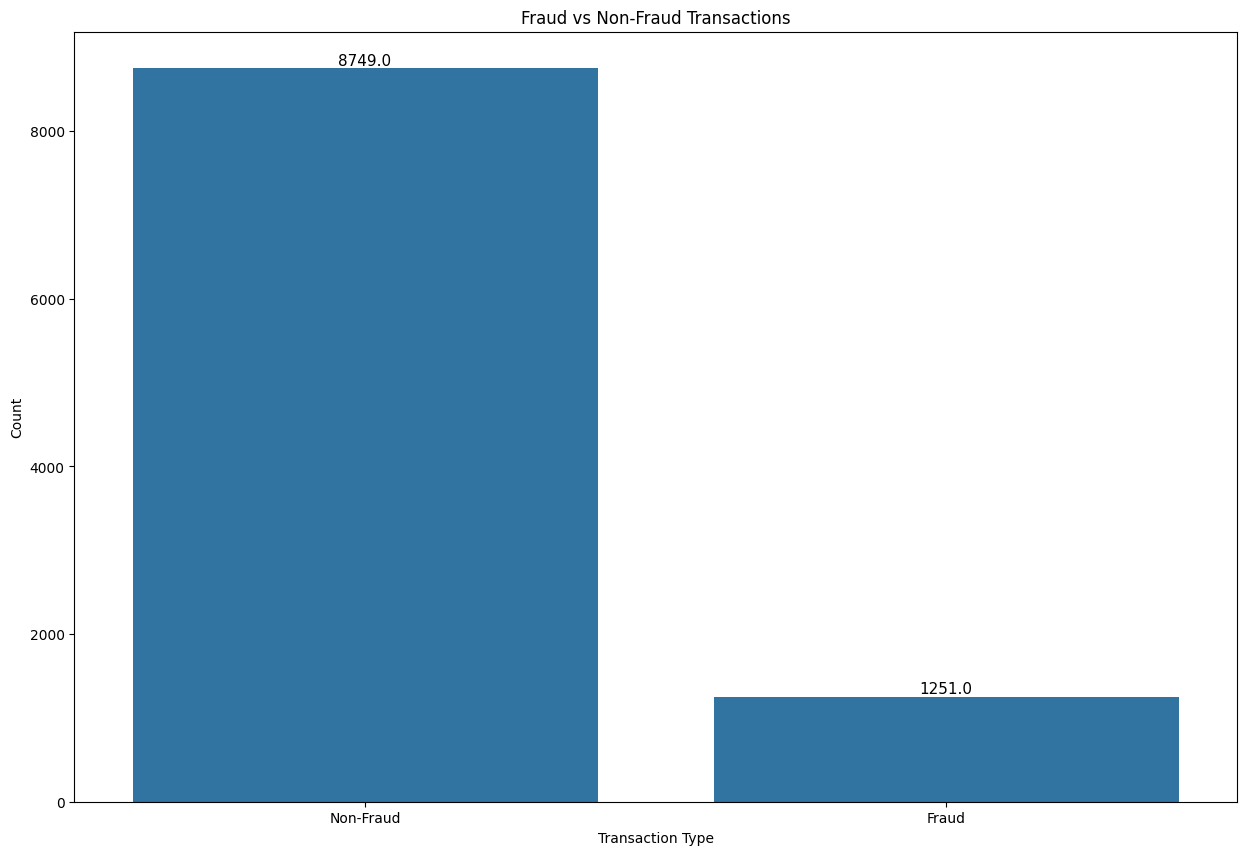

In [9]:
# ============================================================
# CHART 1: Fraud vs Non-Fraud Transactions
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15,10))

ax = sns.countplot(
    x='fraud_category',
    data=df
)

# Add values on bars
for p in ax.patches:
    ax.annotate(
        f'{p.get_height()}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=11
    )

plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("Transaction Type")
plt.ylabel("Count")

plt.show()

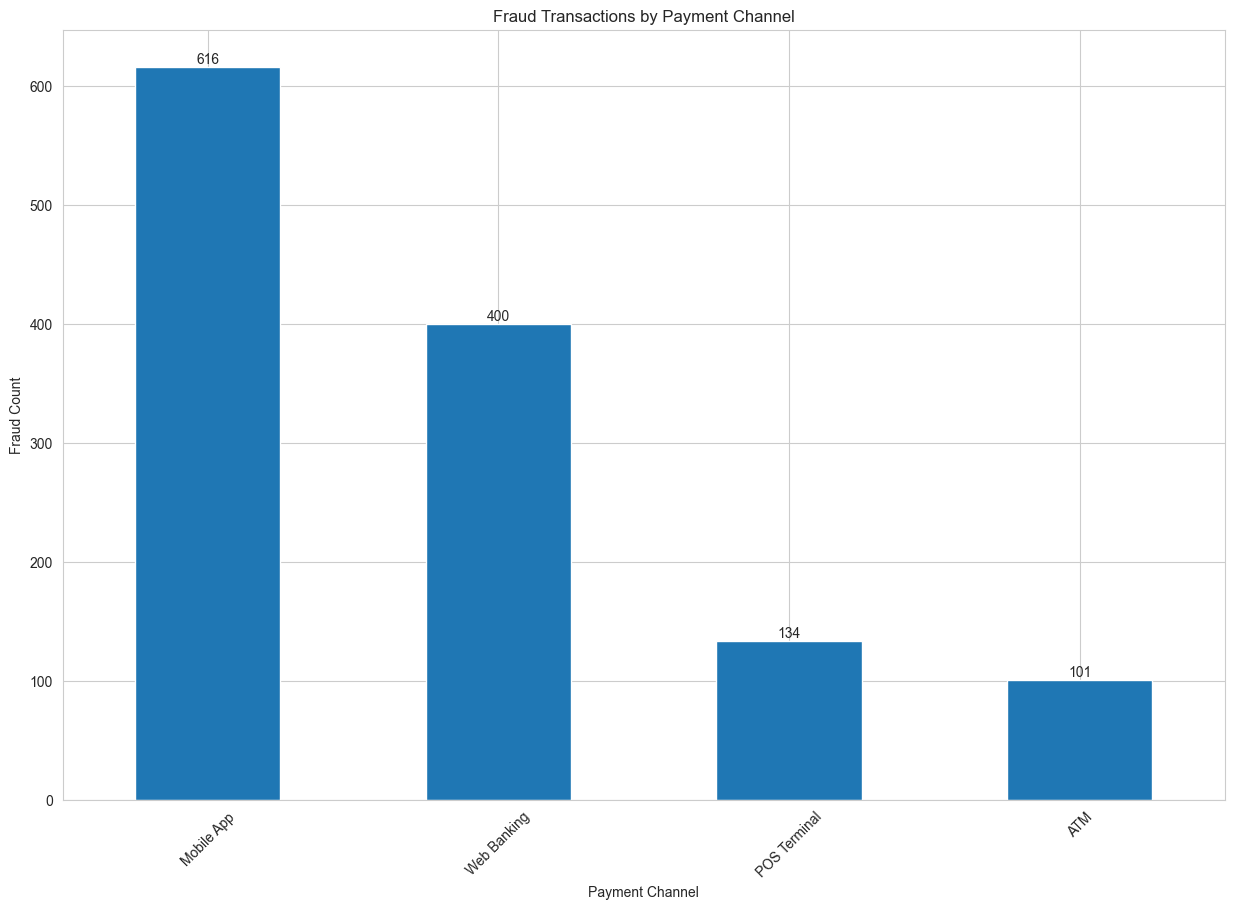

In [15]:
# ============================================================
# CHART 2: Fraud by Payment Channel
# ============================================================

plt.figure(figsize=(15,10))

fraud_channel = df.groupby('payment_channel')['fraud_flag'].sum().sort_values(ascending=False)

ax = fraud_channel.plot(kind='bar')

# Add values on bars
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.title("Fraud Transactions by Payment Channel")
plt.xlabel("Payment Channel")
plt.ylabel("Fraud Count")

plt.xticks(rotation=45)

plt.show()

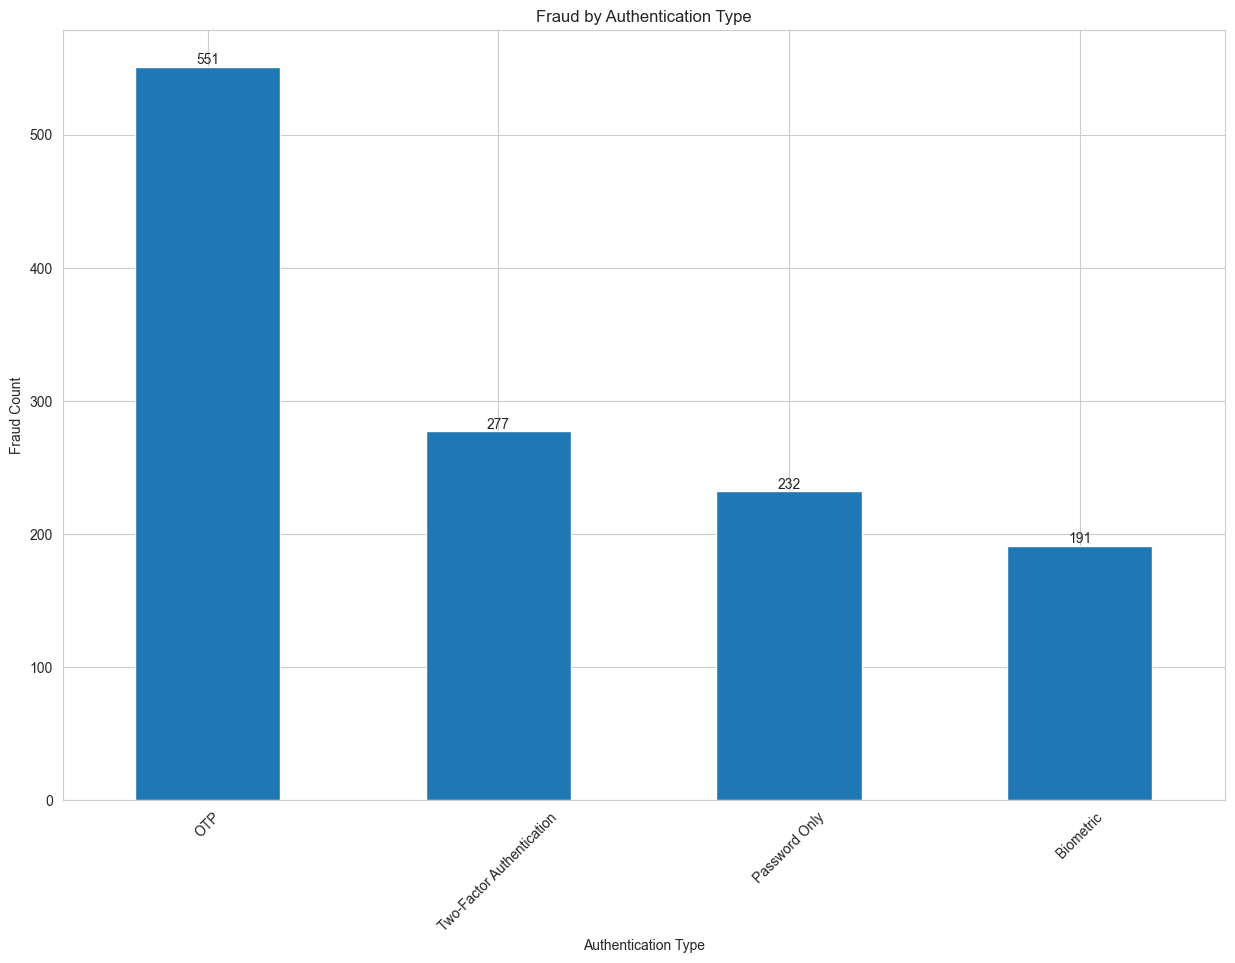

In [16]:
# ============================================================
# CHART 3: Fraud by Authentication Type
# ============================================================

plt.figure(figsize=(15,10))

fraud_auth = df.groupby('authentication_type')['fraud_flag'].sum().sort_values(ascending=False)

ax = fraud_auth.plot(kind='bar')

# Add values on bars
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.title("Fraud by Authentication Type")
plt.xlabel("Authentication Type")
plt.ylabel("Fraud Count")

plt.xticks(rotation=45)

plt.show()

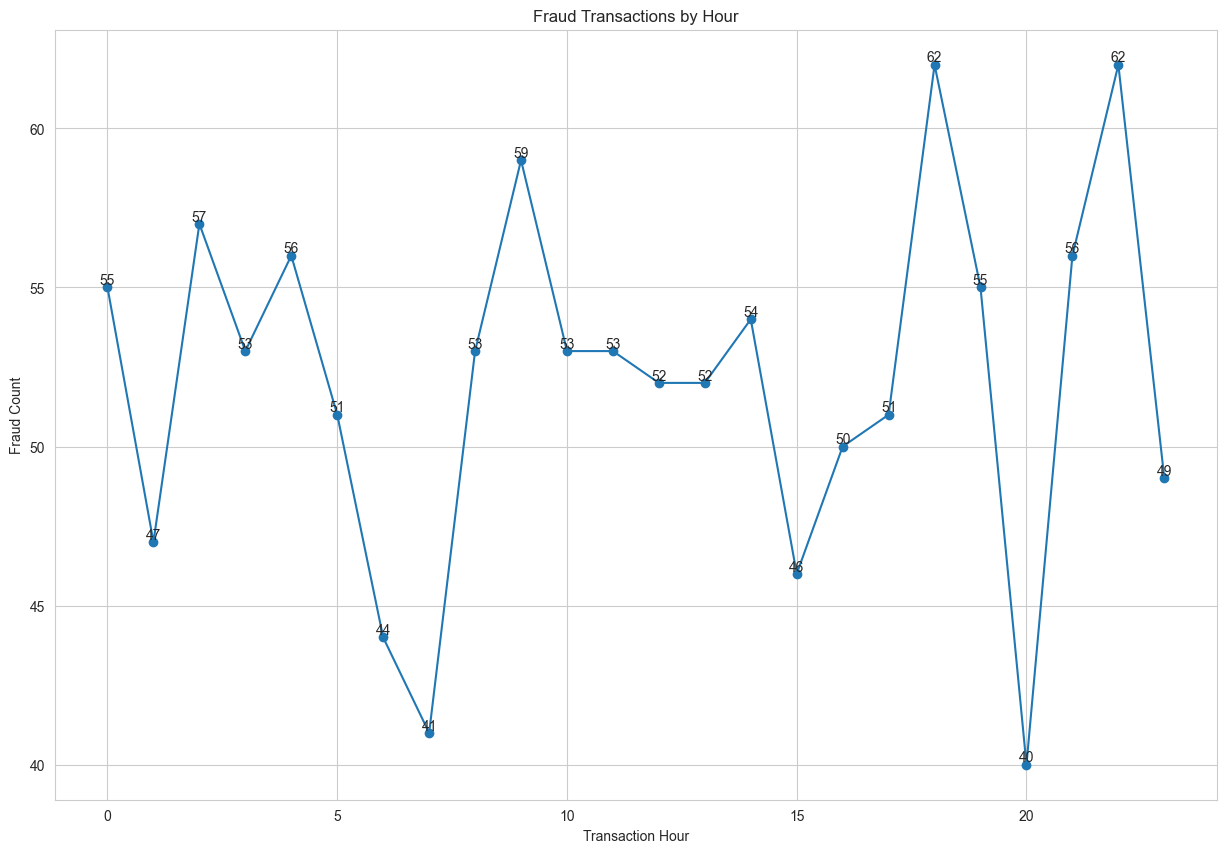

In [17]:
# ============================================================
# CHART 4: Fraud by Transaction Hour
# ============================================================

plt.figure(figsize=(15,10))

fraud_hour = df.groupby('transaction_time_hour')['fraud_flag'].sum()

ax = fraud_hour.plot(kind='line', marker='o')

# Add values on points
for x, y in enumerate(fraud_hour):
    plt.text(x, y, str(y), ha='center', va='bottom')

plt.title("Fraud Transactions by Hour")
plt.xlabel("Transaction Hour")
plt.ylabel("Fraud Count")

plt.show()

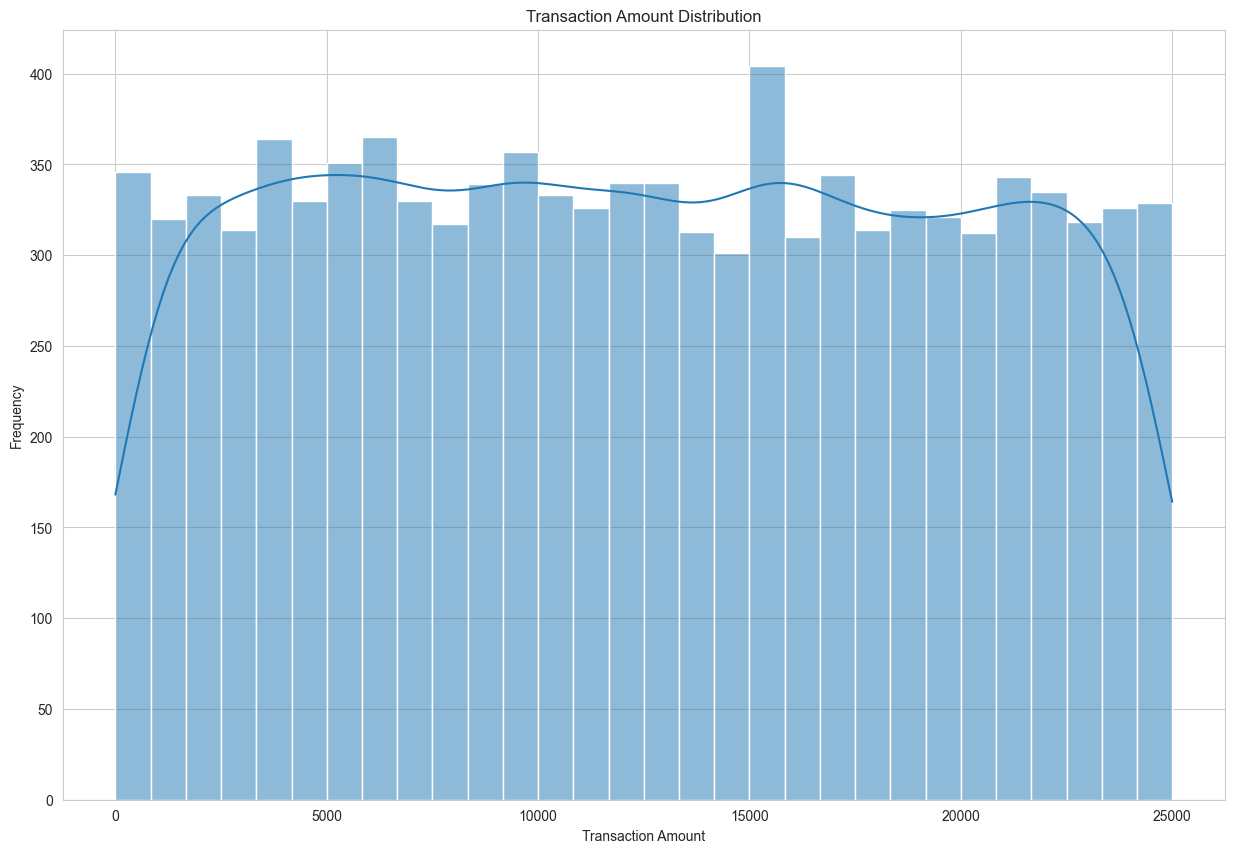

In [18]:
# ============================================================
# CHART 5: Transaction Amount Distribution
# ============================================================

plt.figure(figsize=(15,10))

sns.histplot(
    df['transaction_amount'],
    bins=30,
    kde=True
)

plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.show()

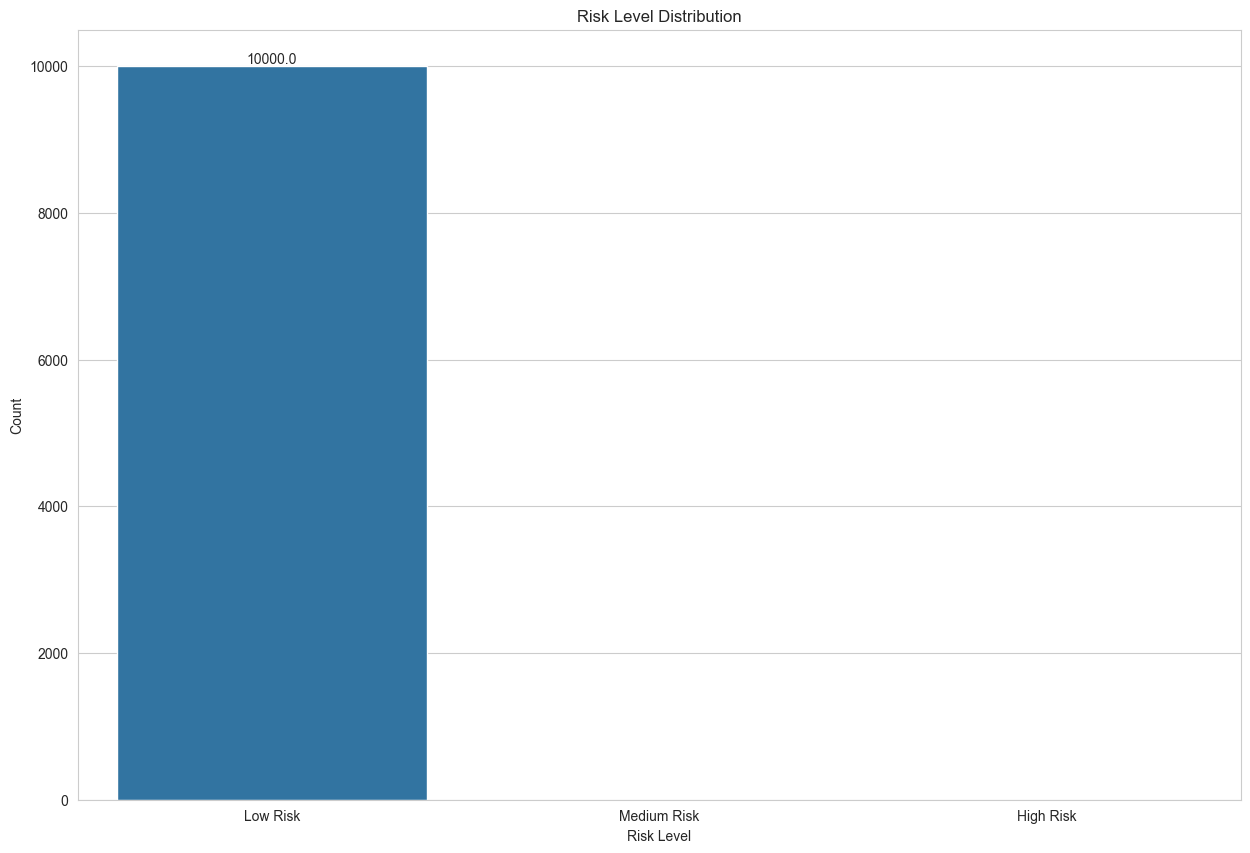

In [19]:
# ============================================================
# CHART 6: Risk Level Distribution
# ============================================================

plt.figure(figsize=(15,10))

ax = sns.countplot(
    x='risk_level',
    data=df
)

# Add values on bars
for p in ax.patches:
    ax.annotate(
        f'{p.get_height()}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.title("Risk Level Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Count")

plt.show()

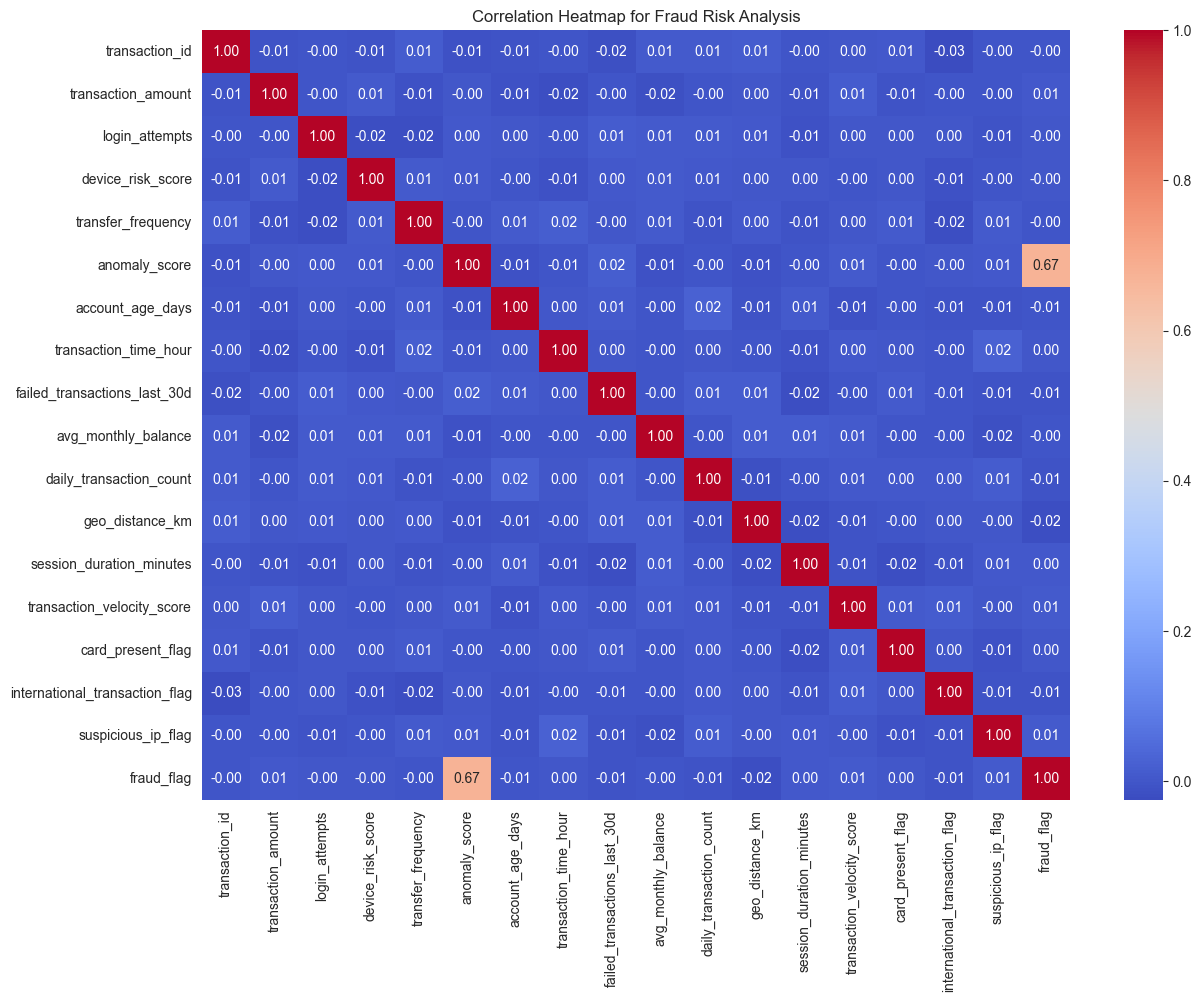

In [20]:
# ============================================================
# STEP 6: CORRELATION ANALYSIS
# Fraud Risk Relationships
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns


# ------------------------------------------------------------
# Select only numerical columns
# ------------------------------------------------------------

numeric_df = df.select_dtypes(include=['int64', 'float64', 'bool'])


# ------------------------------------------------------------
# Convert fraud_flag from Boolean to Integer
# This helps correlation calculations
# ------------------------------------------------------------

numeric_df['fraud_flag'] = numeric_df['fraud_flag'].astype(int)


# ------------------------------------------------------------
# Create correlation matrix
# ------------------------------------------------------------

correlation_matrix = numeric_df.corr()


# ------------------------------------------------------------
# Plot Heatmap
# ------------------------------------------------------------

plt.figure(figsize=(14,10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap for Fraud Risk Analysis")

plt.show()

In [1]:
# ============================================================
# STEP 7.1: IMPORT REQUIRED LIBRARIES
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [10]:
# ============================================================
# STEP 7.2: PREPARE FEATURES AND TARGET VARIABLE
# ============================================================

# Create the feature dataset
# We remove columns that should not be used for model training

X = df.drop(columns=[
    'transaction_id',
    'fraud_flag',
    'fraud_category',
    'risk_level'
], errors='ignore')


# ------------------------------------------------------------
# Convert categorical columns into numeric format
# Machine learning models cannot read text directly
# ------------------------------------------------------------

X = pd.get_dummies(X, drop_first=True)


# ------------------------------------------------------------
# Create the target variable
# This is what the model will learn to predict
# False = 0
# True = 1
# ------------------------------------------------------------

y = df['fraud_flag'].astype(int)


# ------------------------------------------------------------
# Check the final shapes
# ------------------------------------------------------------

print("Feature Dataset Shape:", X.shape)
print("Target Dataset Shape:", y.shape)

Feature Dataset Shape: (10000, 22)
Target Dataset Shape: (10000,)


In [11]:
# ============================================================
# STEP 7.3: TRAIN TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split


# ------------------------------------------------------------
# Split the dataset
# 80% Training
# 20% Testing
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# ------------------------------------------------------------
# Display Shapes
# ------------------------------------------------------------

print("X Train Shape:", X_train.shape)
print("X Test Shape:", X_test.shape)

print("y Train Shape:", y_train.shape)
print("y Test Shape:", y_test.shape)

X Train Shape: (8000, 22)
X Test Shape: (2000, 22)
y Train Shape: (8000,)
y Test Shape: (2000,)


In [12]:
# ============================================================
# STEP 7.4: TRAIN RANDOM FOREST MODEL
# ============================================================

from sklearn.ensemble import RandomForestClassifier


# ------------------------------------------------------------
# Create the Random Forest model
# ------------------------------------------------------------

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)


# ------------------------------------------------------------
# Train the model using training data
# ------------------------------------------------------------

rf_model.fit(X_train, y_train)


print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [13]:
# ============================================================
# STEP 7.5: MAKE PREDICTIONS
# ============================================================

# Predict fraud status on the test data
y_pred = rf_model.predict(X_test)


# Display first 10 predictions
print("First 10 Predictions:")
print(y_pred[:10])

First 10 Predictions:
[0 0 0 1 0 0 1 0 0 0]


In [14]:
# ============================================================
# STEP 7.6: MODEL ACCURACY
# ============================================================

from sklearn.metrics import accuracy_score


# Calculate model accuracy
accuracy = accuracy_score(y_test, y_pred)


print("Model Accuracy:", round(accuracy * 100, 2), "%")

Model Accuracy: 94.95 %


In [15]:
# ============================================================
# STEP 7.7: CLASSIFICATION REPORT
# ============================================================

from sklearn.metrics import classification_report


# Generate classification report
report = classification_report(y_test, y_pred)


print(report)

              precision    recall  f1-score   support

           0       0.97      0.98      0.97      1751
           1       0.82      0.76      0.79       249

    accuracy                           0.95      2000
   macro avg       0.89      0.87      0.88      2000
weighted avg       0.95      0.95      0.95      2000



[[1709   42]
 [  59  190]]


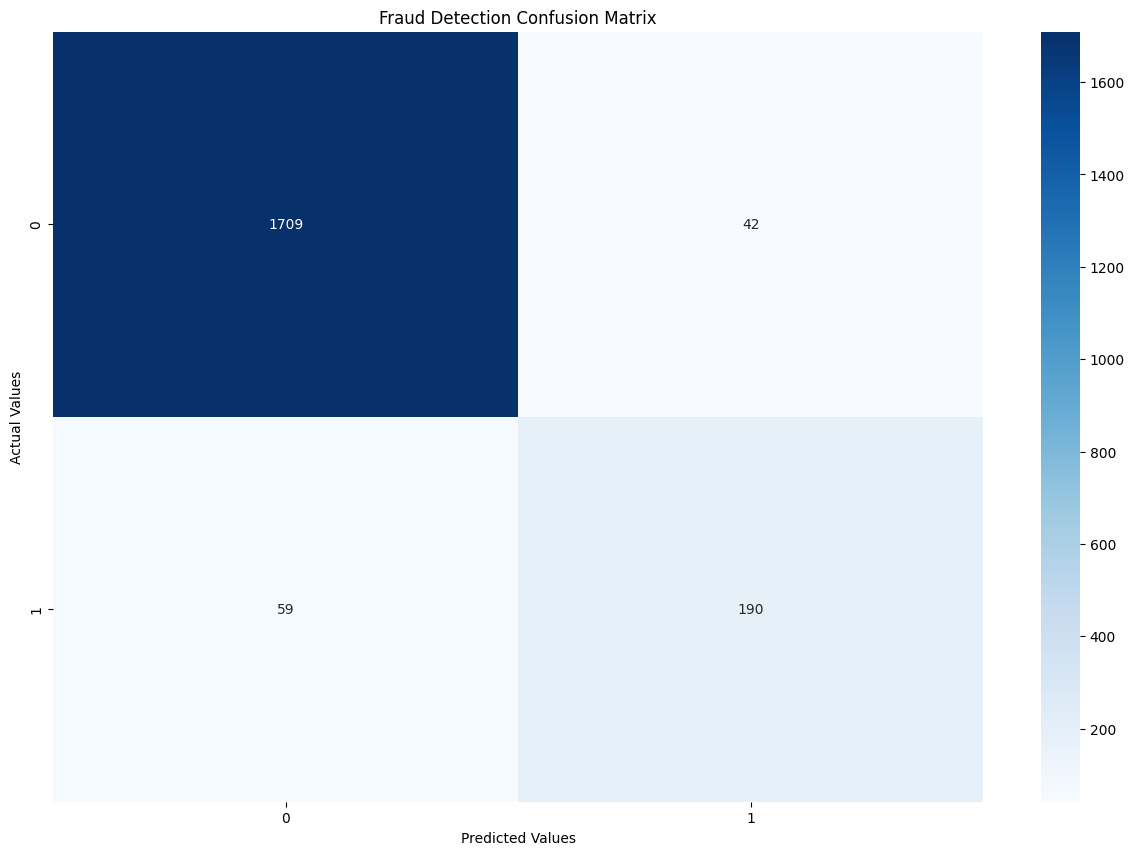

In [17]:
# ============================================================
# STEP 7.8: CONFUSION MATRIX
# ============================================================

from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns


# ------------------------------------------------------------
# Create confusion matrix
# ------------------------------------------------------------

cm = confusion_matrix(y_test, y_pred)


# ------------------------------------------------------------
# Display matrix values
# ------------------------------------------------------------

print(cm)


# ------------------------------------------------------------
# Plot confusion matrix
# ------------------------------------------------------------

plt.figure(figsize=(15,10))

ax = sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)


plt.title("Fraud Detection Confusion Matrix")

plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")


plt.show()

In [18]:
# ============================================================
# STEP 7.9: FEATURE IMPORTANCE ANALYSIS
# ============================================================

# Create feature importance dataframe

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})


# ------------------------------------------------------------
# Sort values from highest to lowest
# ------------------------------------------------------------

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)


# ------------------------------------------------------------
# Display Top 10 Features
# ------------------------------------------------------------

print(feature_importance.head(10))

                       Feature  Importance
4                anomaly_score    0.622411
10             geo_distance_km    0.035856
0           transaction_amount    0.032299
5             account_age_days    0.032217
8          avg_monthly_balance    0.031666
2            device_risk_score    0.031247
9      daily_transaction_count    0.030065
11    session_duration_minutes    0.029830
12  transaction_velocity_score    0.029464
3           transfer_frequency    0.025854


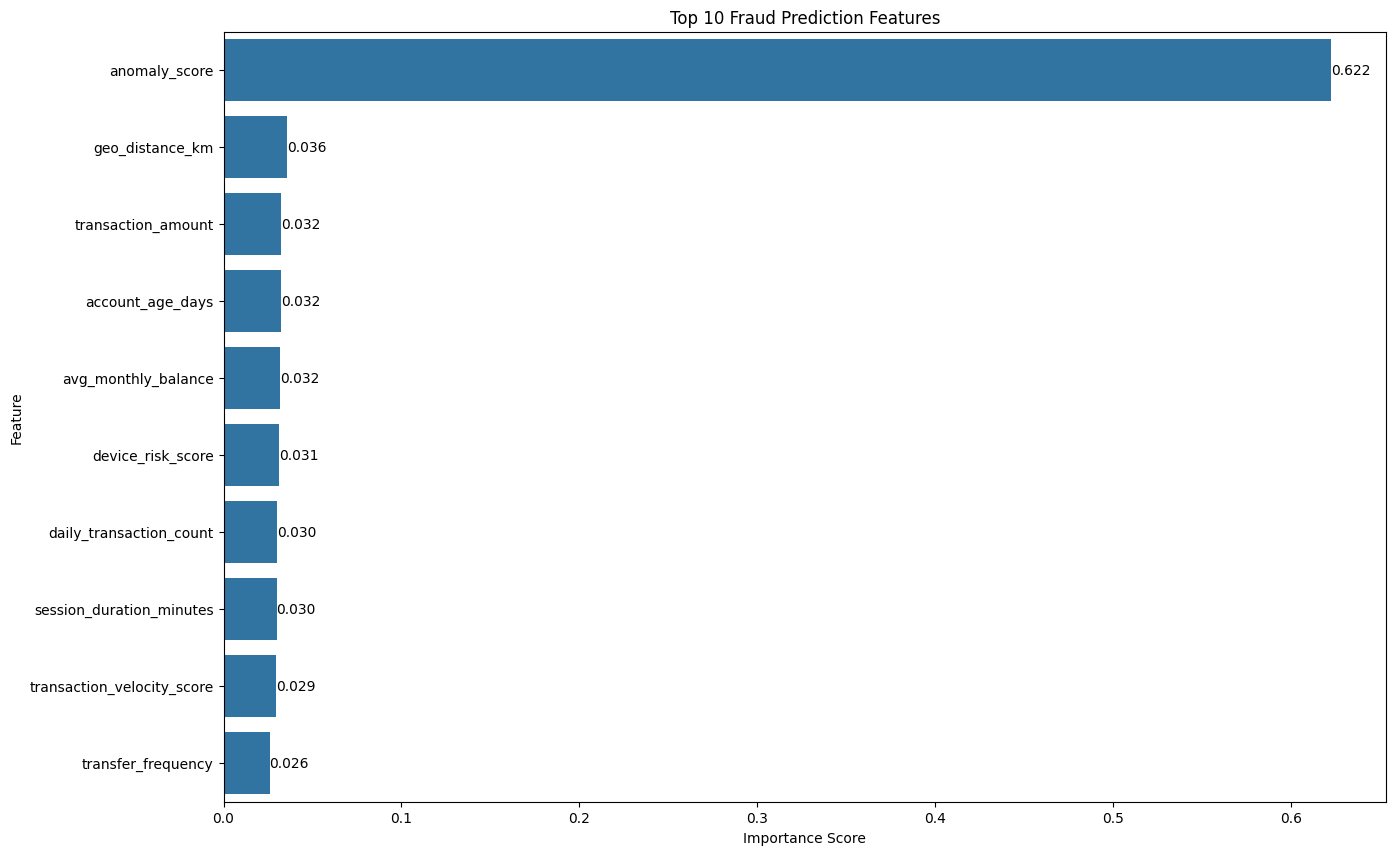

In [20]:
# ============================================================
# STEP 7.10: FEATURE IMPORTANCE CHART
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns


# ------------------------------------------------------------
# Select Top 10 Features
# ------------------------------------------------------------

top_features = feature_importance.head(10)


# ------------------------------------------------------------
# Create Visualization
# ------------------------------------------------------------

plt.figure(figsize=(15,10))

ax = sns.barplot(
    x='Importance',
    y='Feature',
    data=top_features
)


# ------------------------------------------------------------
# Add values on bars
# ------------------------------------------------------------

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f')


# ------------------------------------------------------------
# Chart Formatting
# ------------------------------------------------------------

plt.title("Top 10 Fraud Prediction Features")

plt.xlabel("Importance Score")
plt.ylabel("Feature")


plt.show()

In [21]:
# ============================================================
# FRAUD ANALYTICS DASHBOARD KPIs
# ============================================================

# Total Transactions
total_transactions = len(df)

# Total Fraud Cases
total_fraud = df['fraud_flag'].sum()

# Fraud Rate
fraud_rate = (total_fraud / total_transactions) * 100

# Total Fraud Amount
fraud_amount = df[df['fraud_flag'] == True]['transaction_amount'].sum()

# Average Transaction Amount
avg_transaction = df['transaction_amount'].mean()

# High Risk Transactions
high_risk_transactions = len(
    df[df['risk_level'] == 'High Risk']
)


# ------------------------------------------------------------
# DISPLAY KPI VALUES
# ------------------------------------------------------------

print("="*50)
print("BANKING FRAUD ANALYTICS DASHBOARD")
print("="*50)

print(f"Total Transactions: {total_transactions}")
print(f"Total Fraud Transactions: {total_fraud}")
print(f"Fraud Rate: {fraud_rate:.2f}%")
print(f"Total Fraud Amount: {fraud_amount:,.2f}")
print(f"Average Transaction Amount: {avg_transaction:,.2f}")
print(f"High Risk Transactions: {high_risk_transactions}")

BANKING FRAUD ANALYTICS DASHBOARD
Total Transactions: 10000
Total Fraud Transactions: 1251
Fraud Rate: 12.51%
Total Fraud Amount: 15,657,404.21
Average Transaction Amount: 12,412.75
High Risk Transactions: 0


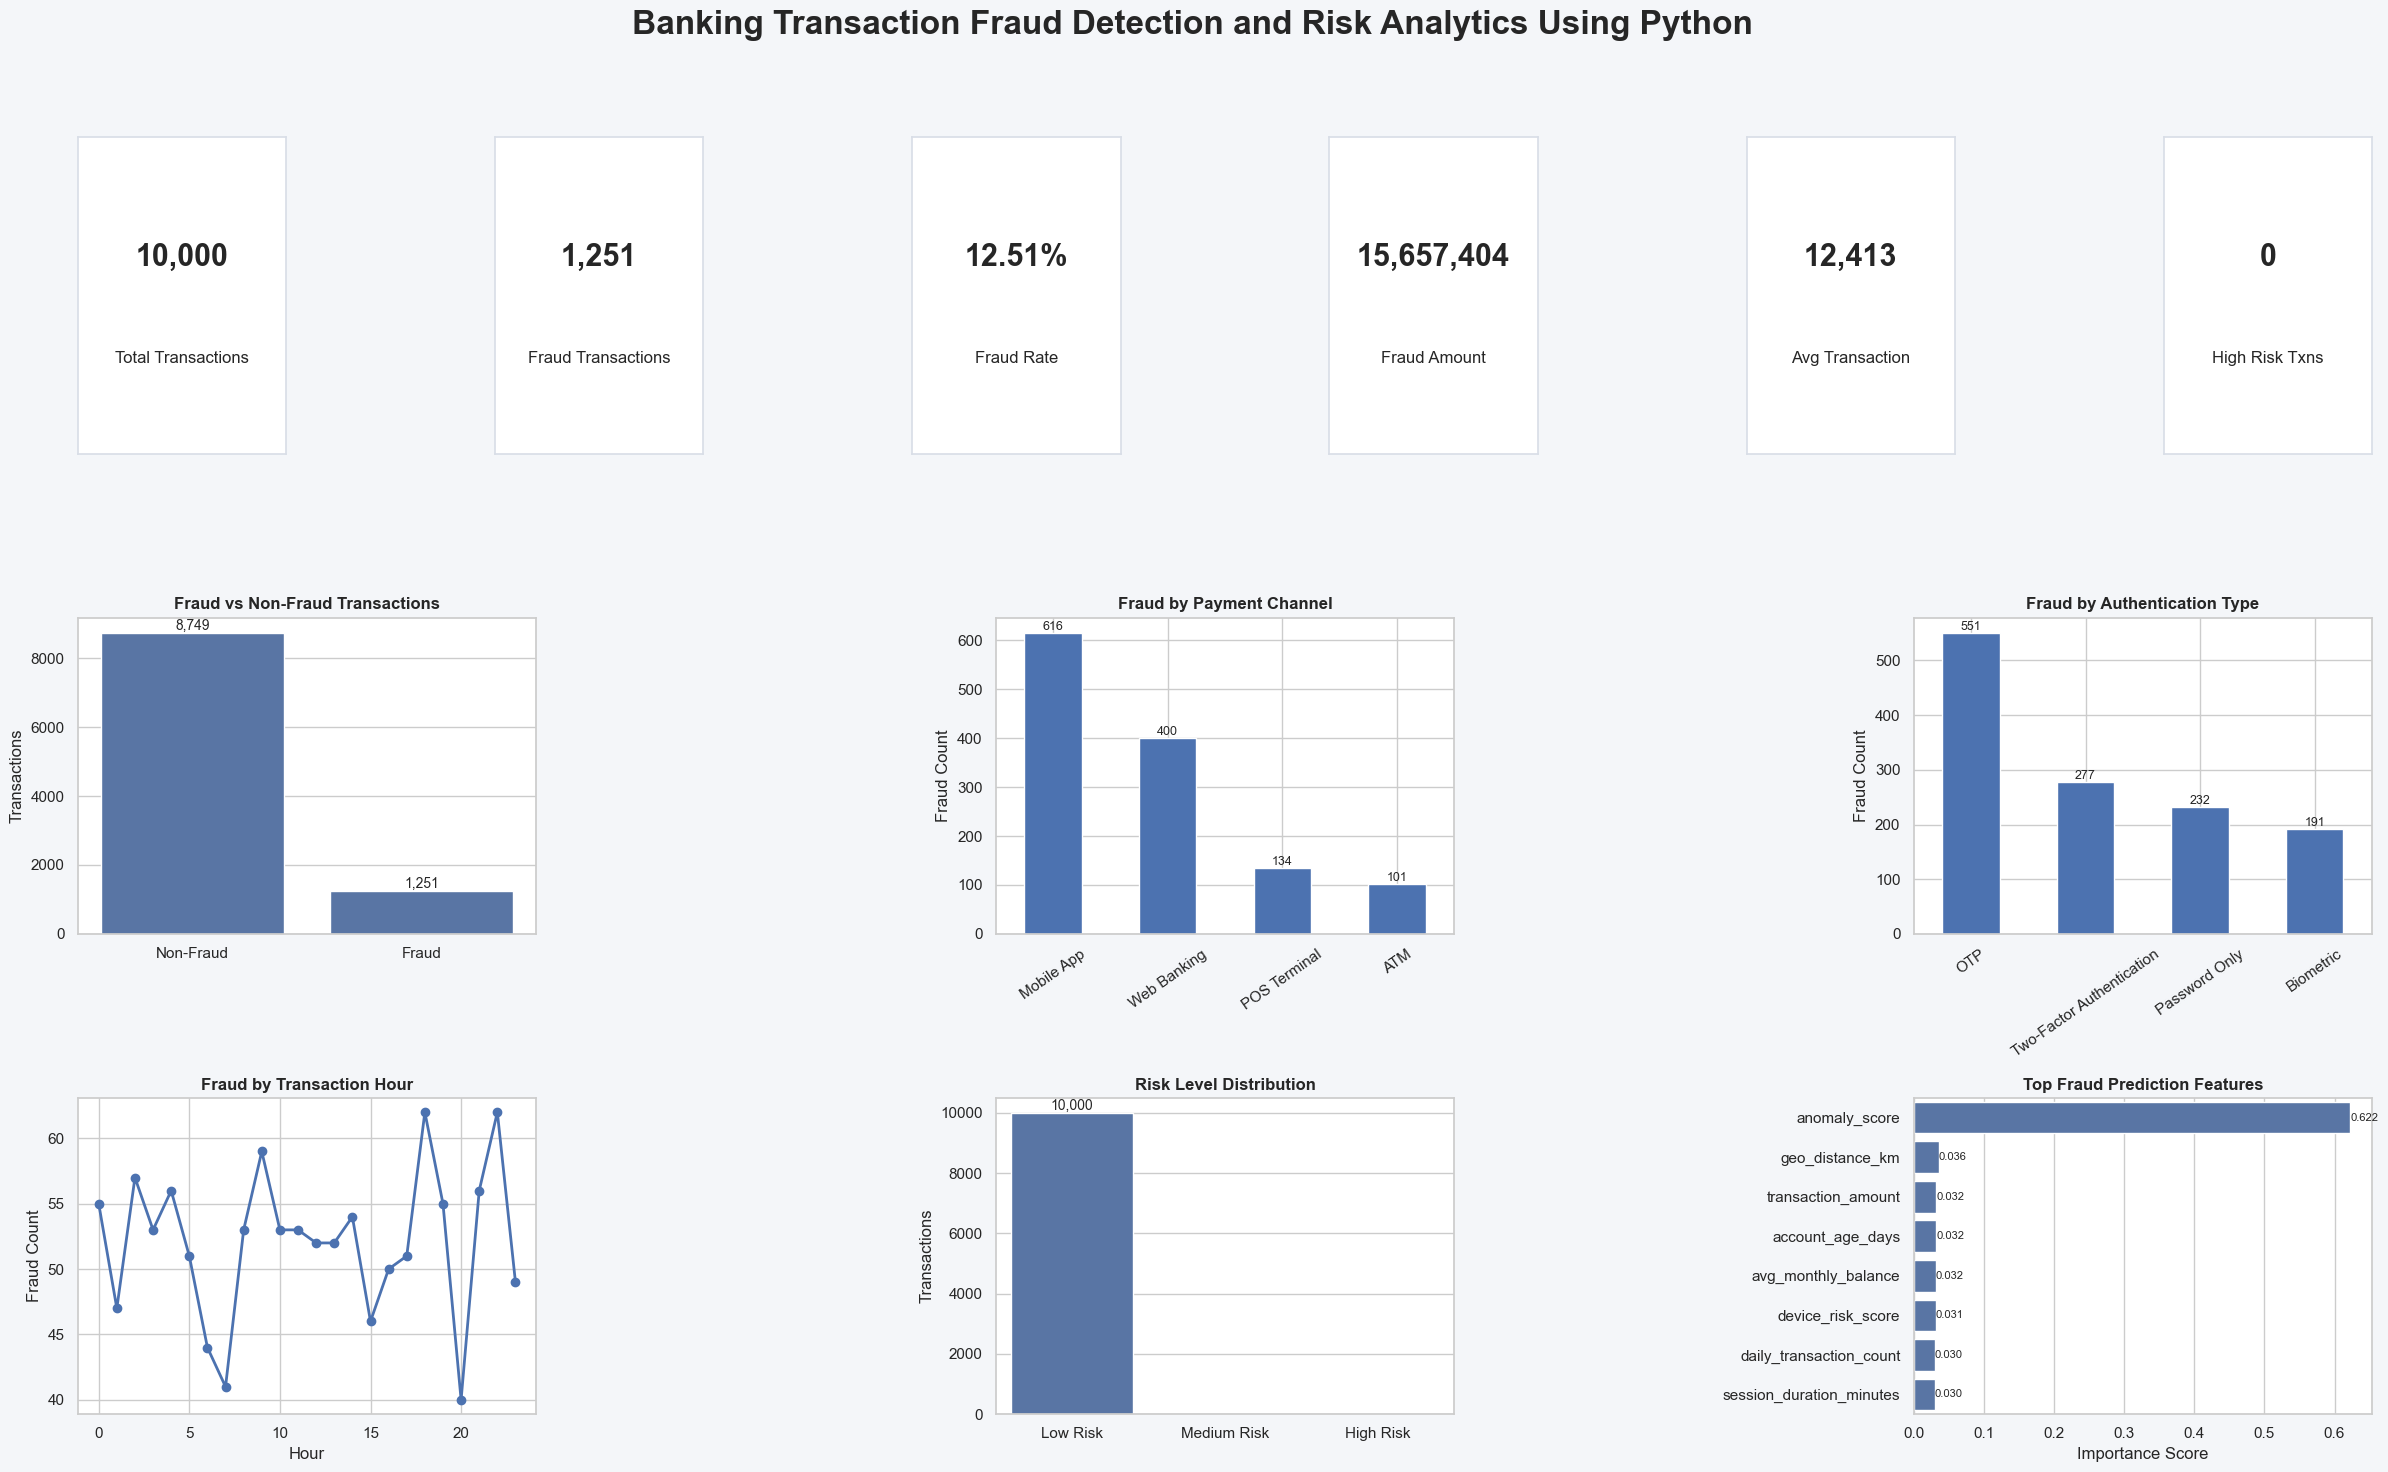

In [24]:
# ============================================================
# PRESENTABLE ONE-PAGE PYTHON DASHBOARD
# Banking Transaction Fraud Detection and Risk Analytics
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# KPI calculations
total_transactions = len(df)
total_fraud = df['fraud_flag'].sum()
fraud_rate = (total_fraud / total_transactions) * 100
fraud_amount = df[df['fraud_flag'] == True]['transaction_amount'].sum()
avg_transaction = df['transaction_amount'].mean()
high_risk_transactions = len(df[df['risk_level'] == 'High Risk'])

# Chart data
fraud_channel = df.groupby('payment_channel')['fraud_flag'].sum().sort_values(ascending=False)
fraud_auth = df.groupby('authentication_type')['fraud_flag'].sum().sort_values(ascending=False)
fraud_hour = df.groupby('transaction_time_hour')['fraud_flag'].sum()
top_features = feature_importance.head(8)

# Dashboard canvas
fig = plt.figure(figsize=(24, 15))
fig.patch.set_facecolor("#F4F6F9")

fig.suptitle(
    "Banking Transaction Fraud Detection and Risk Analytics Using Python",
    fontsize=24,
    fontweight="bold",
    y=0.98
)

# KPI cards
kpis = [
    ("Total Transactions", f"{total_transactions:,}"),
    ("Fraud Transactions", f"{total_fraud:,}"),
    ("Fraud Rate", f"{fraud_rate:.2f}%"),
    ("Fraud Amount", f"{fraud_amount:,.0f}"),
    ("Avg Transaction", f"{avg_transaction:,.0f}"),
    ("High Risk Txns", f"{high_risk_transactions:,}")
]

for i, (title, value) in enumerate(kpis):
    ax = fig.add_subplot(3, 6, i + 1)
    ax.set_facecolor("white")
    ax.text(0.5, 0.62, value, ha="center", va="center", fontsize=22, fontweight="bold")
    ax.text(0.5, 0.30, title, ha="center", va="center", fontsize=12)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_edgecolor("#D9DEE7")

# Chart 1
ax1 = fig.add_subplot(3, 3, 4)
sns.countplot(x="fraud_category", data=df, ax=ax1)
ax1.set_title("Fraud vs Non-Fraud Transactions", fontweight="bold")
ax1.set_xlabel("")
ax1.set_ylabel("Transactions")

for p in ax1.patches:
    ax1.annotate(f"{int(p.get_height()):,}", 
                 (p.get_x() + p.get_width()/2, p.get_height()),
                 ha="center", va="bottom", fontsize=10)

# Chart 2
ax2 = fig.add_subplot(3, 3, 5)
fraud_channel.plot(kind="bar", ax=ax2)
ax2.set_title("Fraud by Payment Channel", fontweight="bold")
ax2.set_xlabel("")
ax2.set_ylabel("Fraud Count")
ax2.tick_params(axis="x", rotation=35)

for p in ax2.patches:
    ax2.annotate(f"{int(p.get_height()):,}", 
                 (p.get_x() + p.get_width()/2, p.get_height()),
                 ha="center", va="bottom", fontsize=9)

# Chart 3
ax3 = fig.add_subplot(3, 3, 6)
fraud_auth.plot(kind="bar", ax=ax3)
ax3.set_title("Fraud by Authentication Type", fontweight="bold")
ax3.set_xlabel("")
ax3.set_ylabel("Fraud Count")
ax3.tick_params(axis="x", rotation=35)

for p in ax3.patches:
    ax3.annotate(f"{int(p.get_height()):,}", 
                 (p.get_x() + p.get_width()/2, p.get_height()),
                 ha="center", va="bottom", fontsize=9)

# Chart 4
ax4 = fig.add_subplot(3, 3, 7)
fraud_hour.plot(kind="line", marker="o", linewidth=2, ax=ax4)
ax4.set_title("Fraud by Transaction Hour", fontweight="bold")
ax4.set_xlabel("Hour")
ax4.set_ylabel("Fraud Count")

# Chart 5
ax5 = fig.add_subplot(3, 3, 8)
sns.countplot(x="risk_level", data=df, ax=ax5)
ax5.set_title("Risk Level Distribution", fontweight="bold")
ax5.set_xlabel("")
ax5.set_ylabel("Transactions")

for p in ax5.patches:
    ax5.annotate(f"{int(p.get_height()):,}", 
                 (p.get_x() + p.get_width()/2, p.get_height()),
                 ha="center", va="bottom", fontsize=10)

# Chart 6
ax6 = fig.add_subplot(3, 3, 9)
sns.barplot(x="Importance", y="Feature", data=top_features, ax=ax6)
ax6.set_title("Top Fraud Prediction Features", fontweight="bold")
ax6.set_xlabel("Importance Score")
ax6.set_ylabel("")

for container in ax6.containers:
    ax6.bar_label(container, fmt="%.3f", fontsize=8)

plt.tight_layout(rect=[0, 0, 1, 0.94])

plt.savefig("banking_fraud_python_dashboard.png", dpi=300, bbox_inches="tight")
plt.show()

In [25]:
# ============================================================
# STEP 8: EXPORT FINAL DASHBOARD DATASET
# Banking Transaction Fraud Detection and Risk Analytics
# ============================================================

# Create a copy of the cleaned dataset
dashboard_df = df.copy()


# ------------------------------------------------------------
# Add ML prediction column
# 0 = Predicted Non-Fraud
# 1 = Predicted Fraud
# ------------------------------------------------------------

dashboard_df['predicted_fraud'] = rf_model.predict(X)


# ------------------------------------------------------------
# Add fraud probability score
# This shows how likely a transaction is to be fraud
# ------------------------------------------------------------

dashboard_df['fraud_probability'] = rf_model.predict_proba(X)[:, 1]


# ------------------------------------------------------------
# Convert probability to percentage
# ------------------------------------------------------------

dashboard_df['fraud_probability_percent'] = dashboard_df['fraud_probability'] * 100


# ------------------------------------------------------------
# Create readable prediction labels
# ------------------------------------------------------------

dashboard_df['predicted_fraud_category'] = dashboard_df['predicted_fraud'].map({
    0: 'Predicted Non-Fraud',
    1: 'Predicted Fraud'
})


# ------------------------------------------------------------
# Create probability risk bands for Power BI slicers
# ------------------------------------------------------------

dashboard_df['ml_risk_band'] = pd.cut(
    dashboard_df['fraud_probability_percent'],
    bins=[0, 30, 60, 80, 100],
    labels=['Low Risk', 'Medium Risk', 'High Risk', 'Critical Risk'],
    include_lowest=True
)


# ------------------------------------------------------------
# Export final file
# ------------------------------------------------------------

dashboard_df.to_csv(
    "banking_fraud_dashboard_data.csv",
    index=False
)


print("Export complete.")
print("File created: banking_fraud_dashboard_data.csv")
print("Rows:", dashboard_df.shape[0])
print("Columns:", dashboard_df.shape[1])

Export complete.
File created: banking_fraud_dashboard_data.csv
Rows: 10000
Columns: 27
